In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [66]:
data = pd.read_csv("../00_Productive_Data/charging_data_clean.csv")
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60922 entries, 0 to 60921
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        60922 non-null  int64  
 1   id                60922 non-null  object 
 2   connectionTime    60922 non-null  object 
 3   disconnectTime    60922 non-null  object 
 4   doneChargingTime  60922 non-null  object 
 5   kWhDelivered      60922 non-null  float64
 6   sessionID         60922 non-null  object 
 7   siteID            60922 non-null  int64  
 8   spaceID           60922 non-null  object 
 9   timezone          60922 non-null  object 
 10  userID            44637 non-null  float64
 11  userInputs        44637 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 5.6+ MB


## Data Preparation for clustering

First all features in the dataset which are of no relevance for the clustering were deleted. Furthermore all datapoints of unregistered users were dropped, since we are going to analyse the behavior of registered users.

In [67]:
data_reg = data.drop(["Unnamed: 0", "id"], axis=1)
data_reg = data_reg.dropna(subset=["userID"])

In [68]:
date_columns = ["connectionTime", "disconnectTime", "doneChargingTime"]

for data in date_columns:
    data_reg[data] = pd.to_datetime(data_reg[data])

def convert_to_local(row): 
    tz = row["timezone"]
    for col in date_columns:
        ts = row[col]
        if pd.isna(ts):
            continue 
        row[col] = ts.tz_convert(tz)
    return row 

data_reg = data_reg.apply(convert_to_local, axis=1)

data_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44637 entries, 2 to 60921
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   connectionTime    44637 non-null  datetime64[ns, America/Los_Angeles]
 1   disconnectTime    44637 non-null  datetime64[ns, America/Los_Angeles]
 2   doneChargingTime  44637 non-null  datetime64[ns, America/Los_Angeles]
 3   kWhDelivered      44637 non-null  float64                            
 4   sessionID         44637 non-null  object                             
 5   siteID            44637 non-null  int64                              
 6   spaceID           44637 non-null  object                             
 7   timezone          44637 non-null  object                             
 8   userID            44637 non-null  float64                            
 9   userInputs        44637 non-null  object                          

### Preparing relevant features

To characterize user behavior, it is essential to analyze both the connection time and the charging duration.

- **Charging duration**: We calculated the charging duration using the features *doneChargingTime* and *connectionTime*.
- **Blocking duration**: Another important feature is the duration for which a vehicle remains connected to the charging station after charging is completed, as this reflects typical user behavior.
- **Blocking ratio**: We also represent blocking behavior as a dimensionless feature by calculating the ratio of blocking duration to total connection duration.
- **Connection hour**: We extracted the hour of the day from the variable *connectionTime*. Since the hour of connection is cyclical, it cannot be directly used as an integer for clustering: for example, hours 23 and 00 are numerically far apart despite being temporally adjacent. Therefore, the connection hour is represented using two variables, *hour_sin* and *hour_cos*.
- **Weekday**: We extracted the day of the week from *connectionTime* and categorized it into weekday and weekend. Only one binary variable was required, as the second category is implicitly defined by the first.

In [69]:
data_reg["blocking_duration_min"] = ((data_reg["disconnectTime"] - data_reg["doneChargingTime"]).dt.total_seconds()/60).round()
data_reg["charging_duration_min"] = ((data_reg["doneChargingTime"] - data_reg["connectionTime"]).dt.total_seconds()/60).round()
data_reg["blocking_ratio"] = data_reg["blocking_duration_min"] / (data_reg["blocking_duration_min"]+data_reg["charging_duration_min"])

data_reg["connection_hour"] = data_reg["connectionTime"].dt.hour
data_reg["con_hour_sin"] = np.sin(2 * np.pi * data_reg["connection_hour"] / 24)
data_reg["con_hour_cos"] = np.cos(2 * np.pi * data_reg["connection_hour"] / 24)

data_reg["weekday"] = data_reg["connectionTime"].dt.dayofweek
data_reg["is_weekday"] = data_reg["weekday"] < 5


We converted the feature *siteID* into a boolean feature for siteID = 1. As before, there is no need for a second feature for siteID = 2, as it is implicity described by the first feature.

In [70]:
data_reg["siteOne"] = (data_reg["siteID"] == 1)

 ### Handling of the User Inputs

The feature *userInputs* was converted and all relevant attributes were extracted into seperate features. As identified during data preparation, most entries contain only one single list, but there are few data points, where the userInput contains multiple lists. These entries are considered invalid and would normally require special handling. One safe approach would be to remove these data points. However, subsequent clustering experiments showed that the *UserInput* attributes are not beeing used for the clustering, making their removal unnecessary. 

In [71]:
import ast
data_reg['userInputs'] = data_reg['userInputs'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [72]:
data_reg["userInputs"] = data_reg["userInputs"].apply(
    lambda x: x[:1] if isinstance(x, list) and len(x) > 1 else x
)

In [73]:
data_reg['userInputs'] = data_reg['userInputs'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) == 1 else {}
)

keys = ['WhPerMile', 'kWhRequested', 'minutesAvailable', 'milesRequested']

for k in keys:
    data_reg[k] = data_reg['userInputs'].apply(lambda d: d.get(k))

data_reg.head(5)

,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,timezone,userID,userInputs,...,connection_hour,con_hour_sin,con_hour_cos,weekday,is_weekday,siteOne,WhPerMile,kWhRequested,minutesAvailable,milesRequested
2,2018-10-09 15:26:40-07:00,2018-10-09 19:48:12-07:00,2018-10-09 19:28:29-07:00,12.034,1_1_193_825_2018-10-09 22:26:39.626134,1,AG-1F01,America/Los_Angeles,383.0,"{'WhPerMile': 400, 'kWhRequested': 15.2, 'mile...",...,15,-0.707107,-7.071068e-01,1,True,True,400,15.200,232,38
7,2018-10-12 10:07:47-07:00,2018-10-12 15:58:22-07:00,2018-10-12 14:46:28-07:00,14.289,1_1_193_825_2018-10-12 17:07:46.566136,1,AG-1F01,America/Los_Angeles,335.0,"{'WhPerMile': 275, 'kWhRequested': 15.125, 'mi...",...,10,0.500000,-8.660254e-01,4,True,True,275,15.125,145,55
8,2018-10-15 06:46:28-07:00,2018-10-15 17:43:30-07:00,2018-10-15 09:03:25-07:00,6.457,1_1_193_825_2018-10-15 13:46:28.073298,1,AG-1F01,America/Los_Angeles,365.0,"{'WhPerMile': 350, 'kWhRequested': 10.15, 'mil...",...,6,1.000000,6.123234e-17,0,True,True,350,10.150,60,29
9,2018-10-16 07:13:50-07:00,2018-10-16 15:03:42-07:00,2018-10-16 10:11:45-07:00,7.416,1_1_193_825_2018-10-16 14:13:49.883021,1,AG-1F01,America/Los_Angeles,374.0,"{'WhPerMile': 400, 'kWhRequested': 16.0, 'mile...",...,7,0.965926,-2.588190e-01,1,True,True,400,16.000,409,40
10,2018-10-16 15:29:34-07:00,2018-10-16 20:30:34-07:00,2018-10-16 18:33:31-07:00,9.909,1_1_193_825_2018-10-16 22:29:34.302430,1,AG-1F01,America/Los_Angeles,467.0,"{'WhPerMile': 425, 'kWhRequested': 21.25, 'mil...",...,15,-0.707107,-7.071068e-01,1,True,True,425,21.250,242,50


In [74]:
data_reg["kWhrequest_difference"] = data_reg["kWhRequested"] - data_reg["kWhDelivered"]
data_reg["kWhrequest_ratio"] = data_reg["kWhDelivered"]/(data_reg["kWhRequested"]+1)
print(data_reg["kWhrequest_difference"].min())
print(data_reg["kWhrequest_difference"].max())

-73.70924166666666
213.686


### Handling outliers

As the clustering process is highly sensitive to outliers, the Interquartile Range (IQR) method was used for outlier detection. Data points containing outliers in the features *blocking_duration_min* and *charging_duration_min* were removed.

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

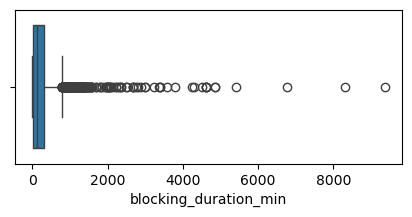

In [76]:
plt.figure(figsize=(5, 2))
sns.boxplot(x=data_reg["blocking_duration_min"])
plt.show()

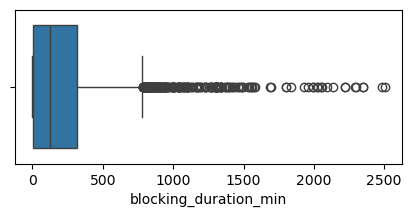

In [77]:
def iqr_outliers(series, lower_k, upper_k):
    Q1 = series.quantile(0.15)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - lower_k * IQR
    upper = Q3 + upper_k * IQR
    return lower, upper

lowerc, upperc = iqr_outliers(
    data_reg["charging_duration_min"], 
    lower_k=1.5, upper_k=5.0
    )

lowerb, upperb = iqr_outliers(
    data_reg["blocking_duration_min"], 
    lower_k=1.5, upper_k=7.0
    )

data_reg = data_reg[
    (data_reg["charging_duration_min"] >= lowerc) &
    (data_reg["charging_duration_min"] <= upperc) &
    (data_reg["blocking_duration_min"] >= lowerb) &
    (data_reg["blocking_duration_min"] <= upperb)
]
plt.figure(figsize=(5, 2))
sns.boxplot(x=data_reg["blocking_duration_min"])
plt.show()



## Create User Dataframe


To carry out user clustering, all relevant features were transformed and aggregated into a user-level data frame.

In [78]:
user_df = (
    data_reg
    .groupby("userID")
    .agg(
        n_sessions=("sessionID", "count"),

        first_session=("connectionTime", "min"),
        last_session=("connectionTime", "max"),
        
        avg_charging_time=("charging_duration_min", "mean"),
        avg_blocking_time=("blocking_duration_min", "mean"),
        blocking_ratio=("blocking_ratio", "mean"),

        weekday_ratio=("is_weekday", "mean"),
        avg_connection_hour_sin=("con_hour_sin", "mean"),
        avg_connection_hour_cos=("con_hour_cos", "mean"),
            
        site_one_ratio=("siteOne", "mean"),

        avg_kWh=("kWhDelivered", "mean"),       
        avg_wh_per_mile=("WhPerMile", "mean"),
        avg_minutes_available=("minutesAvailable", "mean"),
        avg_kWhRequest_ratio=("kWhrequest_ratio", "mean")
    )
    .reset_index()
)

Further key indicator variables were constructed to describe essential aspects of user behavior:

- **Active months**: The number of months during which a user was active, calculated as the time span between the user’s first and last charging session.
- **Active months ratio**: The ratio of a user’s active months to the total observation period. This feature captures how consistently a user was active over the entire dataset timeframe.
- **Sessions per month**: The average number of charging sessions per active month, representing the intensity of usage during periods of activity.
- **Single user**: A binary indicator specifying whether a user has only one recorded charging session during the observation period.

In [79]:
weekOrMonth = 30
observation_start = data_reg['connectionTime'].min()
observation_end = data_reg["connectionTime"].max()
observation_span_months = (observation_end - observation_start).total_seconds()/(60*60*24*weekOrMonth)

user_df["active_months"] = (user_df["last_session"]-user_df["first_session"]).dt.total_seconds()/(60*60*24*weekOrMonth) + 1
user_df["active_months_ratio"] = user_df["active_months"] / observation_span_months
user_df["sessions_per_month"] = user_df["n_sessions"] / user_df["active_months"]

user_df["is_single_user"] = user_df["n_sessions"] == 1


user_df.head(5)

,userID,n_sessions,first_session,last_session,avg_charging_time,avg_blocking_time,blocking_ratio,weekday_ratio,avg_connection_hour_sin,avg_connection_hour_cos,site_one_ratio,avg_kWh,avg_wh_per_mile,avg_minutes_available,avg_kWhRequest_ratio,active_months,active_months_ratio,sessions_per_month,is_single_user
0,1.0,1,2018-06-22 13:11:23-07:00,2018-06-22 13:11:23-07:00,74.000000,10.000000,0.119048,1.0,-0.258819,-0.965926,0.0,1.659000,500.000000,150.000000,0.276500,1.000000,0.024339,1.000000,True
1,17.0,1,2018-11-25 15:40:28-08:00,2018-11-25 15:40:28-08:00,18.000000,0.000000,0.000000,0.0,-0.707107,-0.707107,0.0,1.471000,346.000000,30.000000,0.185732,1.000000,0.024339,1.000000,True
2,22.0,57,2018-04-30 08:07:49-07:00,2020-01-13 12:51:37-08:00,257.052632,129.947368,0.272212,1.0,0.579329,-0.636510,0.0,18.748033,352.631579,461.578947,0.586084,21.774625,0.529965,2.617726,False
3,43.0,1,2018-08-11 09:12:38-07:00,2018-08-11 09:12:38-07:00,419.000000,78.000000,0.156942,0.0,0.707107,-0.707107,0.0,43.266000,217.000000,469.000000,0.974459,1.000000,0.024339,1.000000,True
4,45.0,1,2018-09-16 17:00:47-07:00,2018-09-16 17:00:47-07:00,129.000000,84.000000,0.394366,0.0,-0.965926,-0.258819,0.0,8.069000,250.000000,134.000000,0.436162,1.000000,0.024339,1.000000,True


## Feature selection and scaling

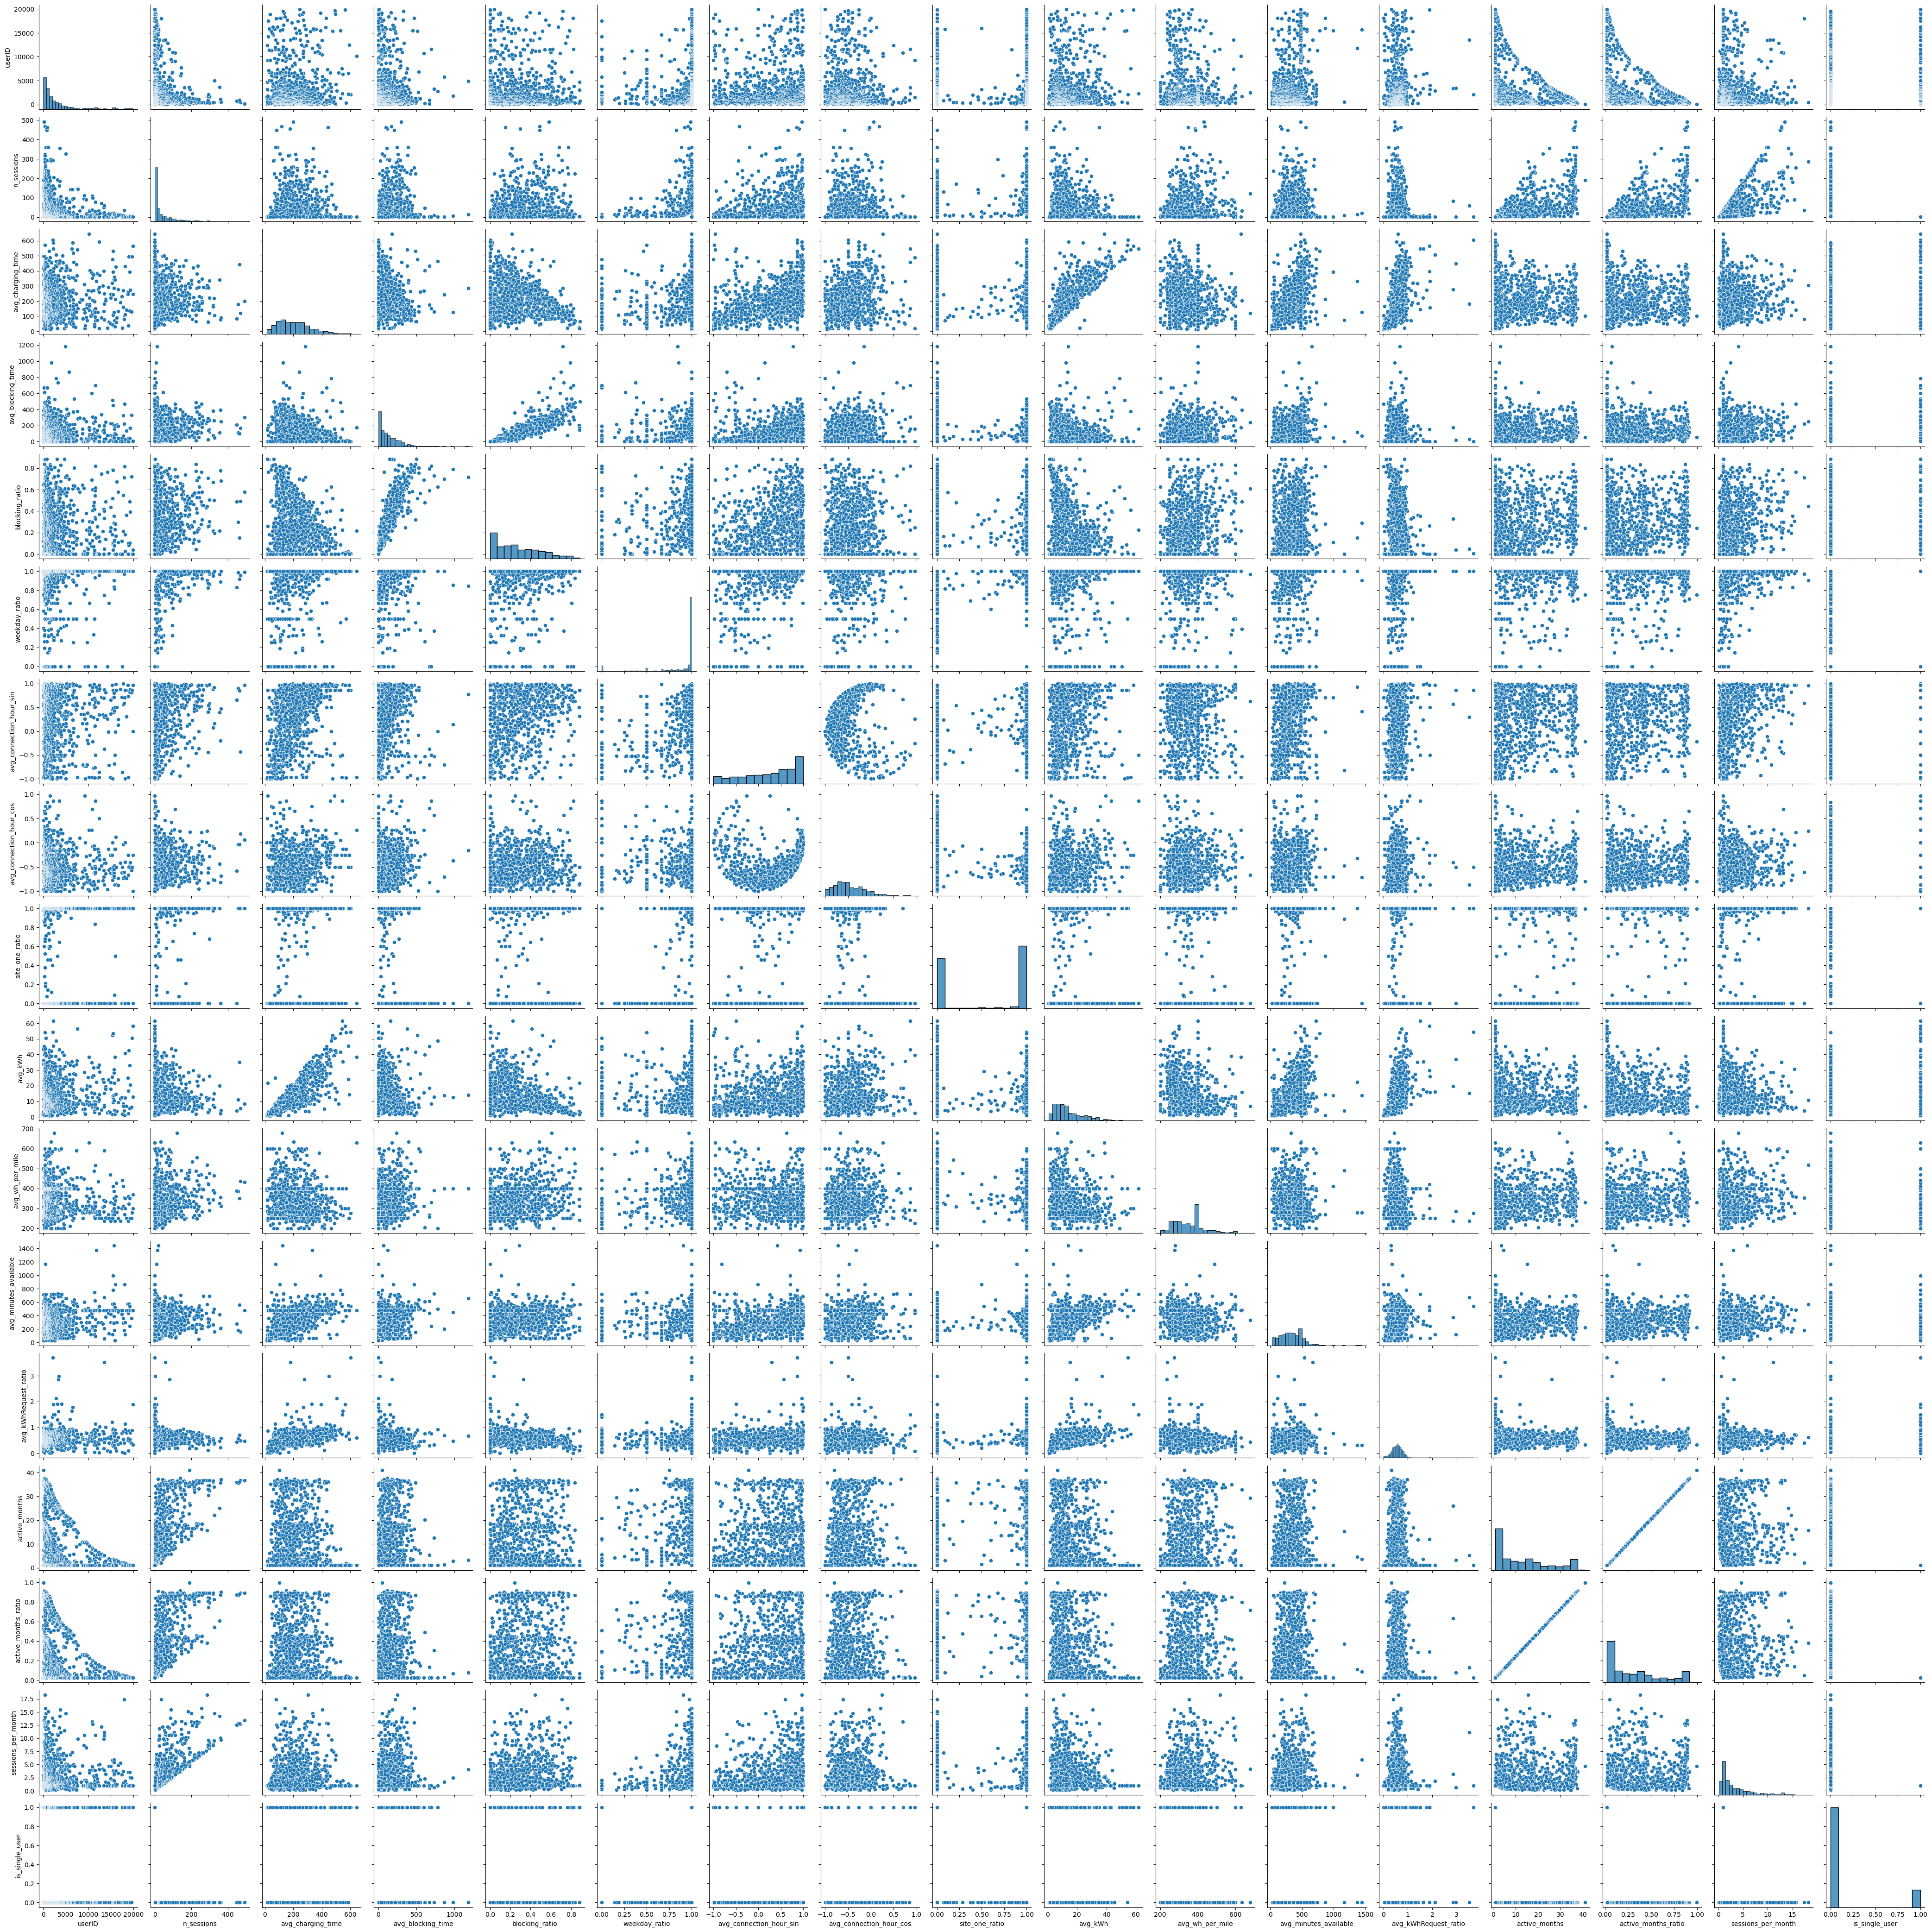

In [80]:
sns.pairplot(user_df)
plt.show()

In [81]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram
%matplotlib inline

### Feature selection

Prior to the feature reduction process, technical and intermediate variables that were only required for feature construction were removed. These include *userID*, *n_sessions*, *first_session*, *last_session*, and *active_weeks*, as they do not represent independent behavioral characteristics and are either identifiers or redundant with derived features.


In [82]:
X = user_df.drop(["userID","n_sessions","first_session", "last_session", "active_months"], axis=1)
X

,avg_charging_time,avg_blocking_time,blocking_ratio,weekday_ratio,avg_connection_hour_sin,avg_connection_hour_cos,site_one_ratio,avg_kWh,avg_wh_per_mile,avg_minutes_available,avg_kWhRequest_ratio,active_months_ratio,sessions_per_month,is_single_user
0,74.000000,10.000000,0.119048,1.0,-2.588190e-01,-0.965926,0.0,1.659000,500.000000,150.000000,0.276500,0.024339,1.000000,True
1,18.000000,0.000000,0.000000,0.0,-7.071068e-01,-0.707107,0.0,1.471000,346.000000,30.000000,0.185732,0.024339,1.000000,True
2,257.052632,129.947368,0.272212,1.0,5.793294e-01,-0.636510,0.0,18.748033,352.631579,461.578947,0.586084,0.529965,2.617726,False
3,419.000000,78.000000,0.156942,0.0,7.071068e-01,-0.707107,0.0,43.266000,217.000000,469.000000,0.974459,0.024339,1.000000,True
4,129.000000,84.000000,0.394366,0.0,-9.659258e-01,-0.258819,0.0,8.069000,250.000000,134.000000,0.436162,0.024339,1.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,272.333333,168.666667,0.392776,1.0,8.796528e-01,-0.408248,1.0,20.585333,251.000000,480.000000,0.788710,0.028322,2.578077,False
884,129.000000,332.000000,0.719785,1.0,8.130525e-01,-0.569036,1.0,6.256000,250.000000,360.000000,0.387244,0.029175,2.502691,False
885,494.000000,0.000000,0.000000,1.0,8.660254e-01,-0.500000,1.0,50.536000,278.000000,480.000000,0.892862,0.024339,1.000000,True
886,565.000000,0.000000,0.000000,1.0,9.659258e-01,-0.258819,0.0,58.354000,300.000000,480.000000,1.882387,0.024339,1.000000,True


To minimize the curse of dimensionality and improve cluster stability, we further reduced the remaining feature set by systematically removing redundant and low-informative variables.

- **Activity features**: The binary feature *is_single_user* does not provide additional information beyond the continuous activity measures *sessions_per_month* and *active_months_ratio*, as single-session users are uniquely identifiable through these variables. Therefore, *is_single_user* is removed.

- **charging and blocking behavior**: Charging duration and blocking behavior capture essential aspects of user interaction with the charging infrastructure. A comparison of the results using *avg_blocking_time* and *blocking_ratio* shows clearer and more unique clusterresults when using *avg_blocking_time*. The feature *avg_kWh* is highly correlated with *avg_charging_time*, resulting in limited additional information for clustering. We evaluated an alternative *kWhRequest_ratio* to represent the discrepancy between user expectations and actual charging behavior; however, empirical tests showed no substantial improvement in cluster separation. Consequently, this feature was excluded to maintain a compact and interpretable feature space.

- **temporal behavior**: The features *weekday_ratio*, *avg_connection_hour_sin*, and *avg_connection_hour_cos* encode complementary temporal usage patterns, but the test results showed, that the connection hour has little variation across clusters and extracting it produces much better silhouette scores. Therefore only the weekday ratio is retained.

- **Location Context**: Since charging behavior differs between private and public locations, the feature *site_one_ratio* provides relevant contextual information and is kept.

- **Additional User Characteristics**: The features *avg_wh_per_mile* and *avg_minutes_available* were evaluated empirically. Both showed limited variation across clusters, and their inclusion consistently reduced the silhouette score. As they did not contribute meaningfully to cluster differentiation, they were removed.

In [83]:
X = X.drop(["is_single_user","blocking_ratio","avg_kWh","avg_kWhRequest_ratio", "avg_wh_per_mile", "avg_minutes_available", "avg_connection_hour_sin","avg_connection_hour_cos"], axis=1)
X

,avg_charging_time,avg_blocking_time,weekday_ratio,site_one_ratio,active_months_ratio,sessions_per_month
0,74.000000,10.000000,1.0,0.0,0.024339,1.000000
1,18.000000,0.000000,0.0,0.0,0.024339,1.000000
2,257.052632,129.947368,1.0,0.0,0.529965,2.617726
3,419.000000,78.000000,0.0,0.0,0.024339,1.000000
4,129.000000,84.000000,0.0,0.0,0.024339,1.000000
...,...,...,...,...,...,...
883,272.333333,168.666667,1.0,1.0,0.028322,2.578077
884,129.000000,332.000000,1.0,1.0,0.029175,2.502691
885,494.000000,0.000000,1.0,1.0,0.024339,1.000000
886,565.000000,0.000000,1.0,0.0,0.024339,1.000000


### Scaling

Since severe outliers were removed prior to clustering, the remaining feature distributions are sufficiently well-behaved. Therefore, StandardScaler is preferred over RobustScaler to preserve relative distances between observations.

In [84]:
use_robust = False
if (use_robust):
    scaler = RobustScaler()
else: scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Clustering

At first, both clustering algorithms - K-Means and Agglomerative clustering - were implemented, and their results were compared based on the silhouette score for varying numbers of clusters. After analyzing these results, only one algorithm was selected.

### K-Means CLustering

In [95]:
kclusters = []
klabels = pd.DataFrame()
ksil_scores = []
klosses = []

for k in range(2, 14):
    cluster = str(k)
    kclusters.append(k)
    kmodel = KMeans(n_clusters=k, random_state=42)
    label = kmodel.fit_predict(X_scaled)
    klabels[cluster] = label
    ksil_scores.append(silhouette_score(X_scaled, klabels[cluster]))
    klosses.append(kmodel.inertia_)

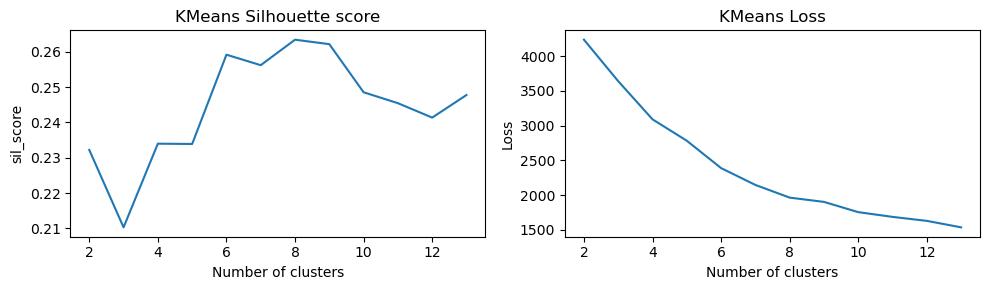

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(kclusters, ksil_scores)
axes[0].set_ylabel("sil_score")
axes[0].set_xlabel("Number of clusters")
axes[0].set_title("KMeans Silhouette score")

axes[1].plot(kclusters, klosses)
axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Number of clusters")
axes[1].set_title("KMeans Loss")

plt.tight_layout()
plt.show()

### Agglomerative Clustering

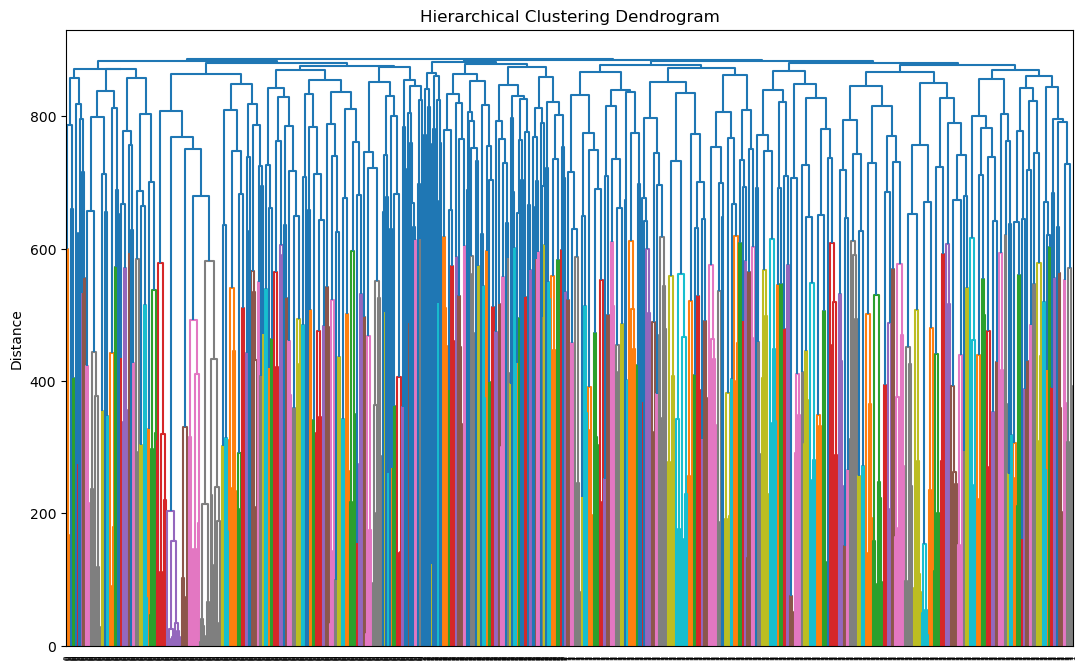

In [87]:
aclusters = []
alabels = pd.DataFrame()
asil_scores = []
alosses = []

def plot_dendrogram(model, **kwargs):

    children = model.children_
    distance = np.arange(children.shape[0])

    no_of_observations = np.arange(2, children.shape[0]+2)
    linkage_matrix = np.column_stack([children, distance, no_of_observations]).astype(float)

    dendrogram(linkage_matrix, **kwargs)

agglo = AgglomerativeClustering(n_clusters=3) 
y_pred_agglo = agglo.fit_predict(X_scaled)

plt.figure(figsize=(13,8))
plt.title('Hierarchical Clustering Dendrogram')
plot_dendrogram(agglo, labels=agglo.labels_)
plt.ylabel("Distance")
plt.show()

for k in range(2, 14):
    cluster = str(k)
    aclusters.append(k)
    amodel = AgglomerativeClustering(n_clusters=k)
    label = amodel.fit_predict(X_scaled)
    alabels[cluster] = label
    asil_scores.append(silhouette_score(X_scaled, label))

Text(0.5, 1.0, 'Agglomerative silhouette score')

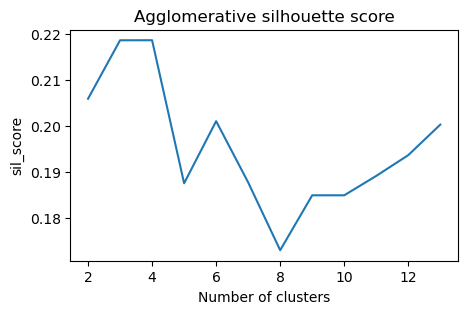

In [88]:
plt.figure(figsize=(5,3))
plt.plot(aclusters, asil_scores)
plt.ylabel("sil_score")
plt.xlabel("Number of clusters")
plt.title(f"Agglomerative silhouette score")

### Hyperparameter Selection

The choice of the clustering algorithm and the number of clusters was guided by a combination of quantitative evaluation metrics and domain knowledge. Comparing silhouette scores across different numbers of clusters, K-Means consistently achieved higher values than agglomerative clustering for most configurations. Consequently, K-Means was selected as the final clustering algorithm.

The selection of the number of clusters additionally incorporated domain-specific considerations. The chosen feature set enables differentiation of users based on charging and blocking behavior, location preference, and usage frequency. A small number of clusters (e.g., three or four) was therefore considered too coarse to capture the diversity of observed charging behaviors. Conversely, a large number of clusters (e.g., more than eight) risks overfitting and results in groups that are difficult to interpret from a domain perspective.

Both evaluation metrics support a six-cluster solution. The silhouette score exhibits a clear local maximum at k = 6, while the K-Means loss (inertia) curve shows an elbow-like behavior at the same value. Based on this alignment of quantitative metrics and domain interpretability, k = 6 was selected as the final number of clusters.


In [89]:
best_cluster = str(6)
X["labels"] = klabels[best_cluster]
X.head(5)

,avg_charging_time,avg_blocking_time,weekday_ratio,site_one_ratio,active_months_ratio,sessions_per_month,labels
0,74.000000,10.000000,1.0,0.0,0.024339,1.000000,0
1,18.000000,0.000000,0.0,0.0,0.024339,1.000000,2
2,257.052632,129.947368,1.0,0.0,0.529965,2.617726,0
3,419.000000,78.000000,0.0,0.0,0.024339,1.000000,2
4,129.000000,84.000000,0.0,0.0,0.024339,1.000000,2


## Cluster analysis

Multiple visual and statistical representations were used to analyze the resulting clusters and their feature values. Cluster characteristics were examined by comparing mean values, within-cluster variability, and relative differences across clusters. All results can also be viewed in the folder *Cluster_results_analysis*.

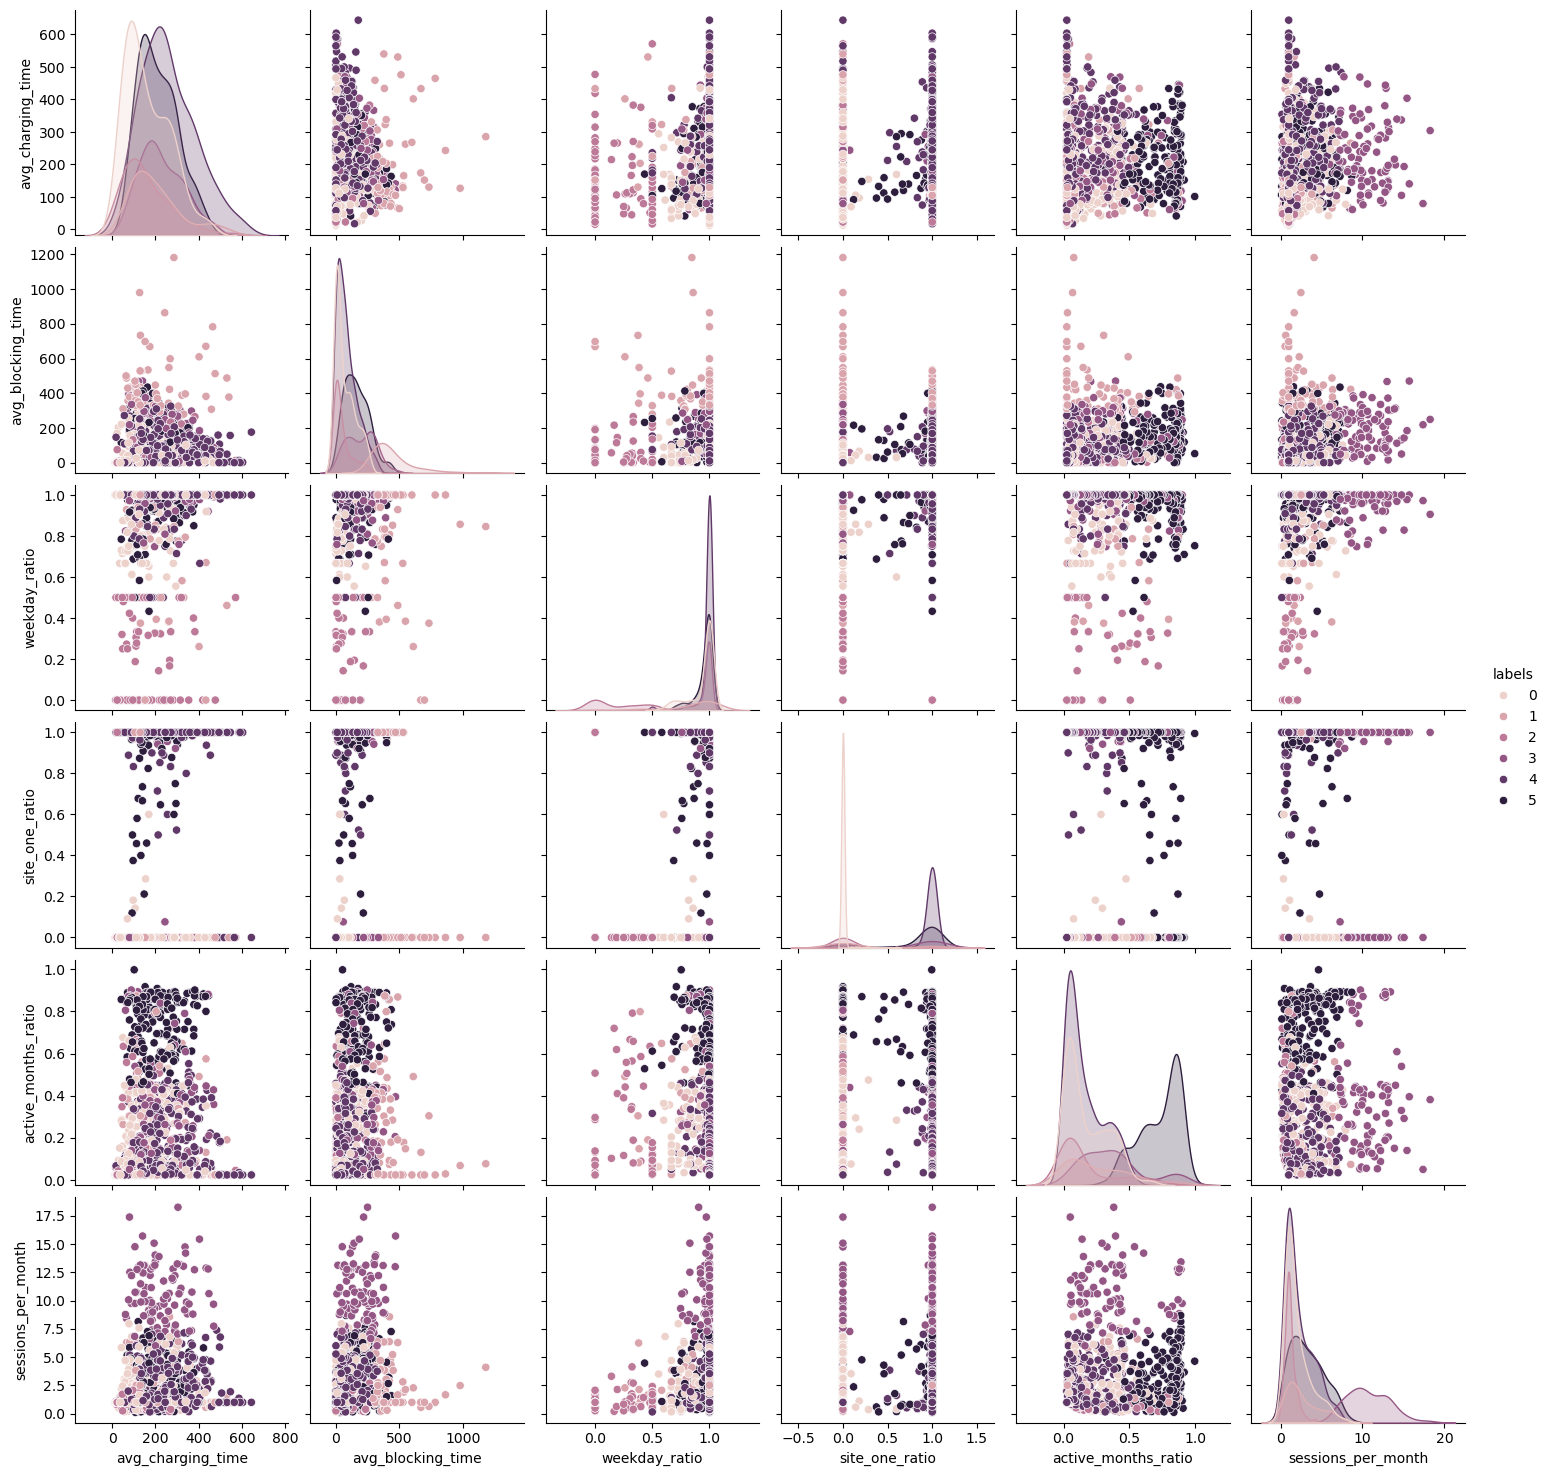

In [90]:
sns.pairplot(X, hue="labels")
plt.savefig("Cluster_results_analysis/Pairplot")
plt.show()

In [91]:
X[X["labels"] == 5].describe()

,avg_charging_time,avg_blocking_time,weekday_ratio,site_one_ratio,active_months_ratio,sessions_per_month,labels
count,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000,189.0
mean,211.354134,161.364192,0.947301,0.801275,0.729981,3.248777,5.0
std,90.492682,96.941096,0.093225,0.368701,0.155120,2.029956,0.0
min,41.607843,0.370370,0.432990,0.000000,0.303573,0.116076,5.0
25%,139.711628,78.619497,0.934498,0.909091,0.611686,1.587023,5.0
50%,198.918182,149.016949,0.991667,1.000000,0.787088,2.866945,5.0
75%,275.908046,230.660714,1.000000,1.000000,0.862429,4.746707,5.0
max,446.188119,437.708333,1.000000,1.000000,0.997092,8.689716,5.0


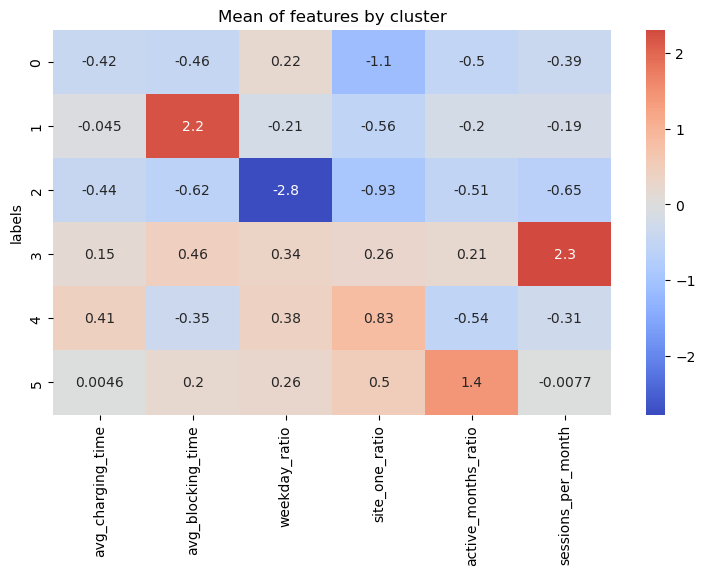

In [92]:
feature_cols = X.columns.drop("labels")

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_cols,
    index=X.index
)

X_scaled_df["labels"] = X["labels"]
features = X_scaled_df.columns.drop("labels")
cluster_means = X_scaled_df.groupby("labels")[features].mean()

plt.figure(figsize=(9, 5))
sns.heatmap(
    cluster_means,
    annot=True,
    cmap="coolwarm",
    center=0

)
plt.title("Mean of features by cluster")
plt.savefig("Cluster_results_analysis/Heatmap_means")
plt.show()

In [93]:
X["labels"].value_counts().sort_index()

labels
0    201
1     67
2     76
3     96
4    259
5    189
Name: count, dtype: int64

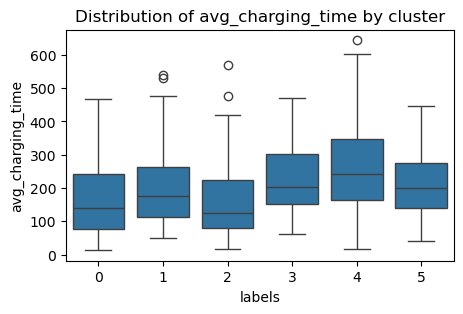

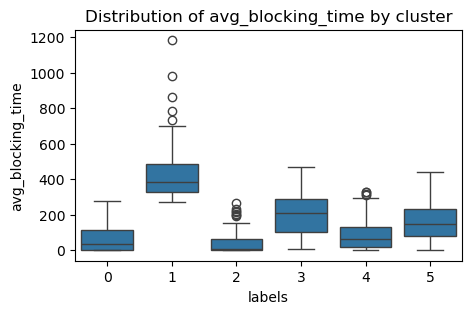

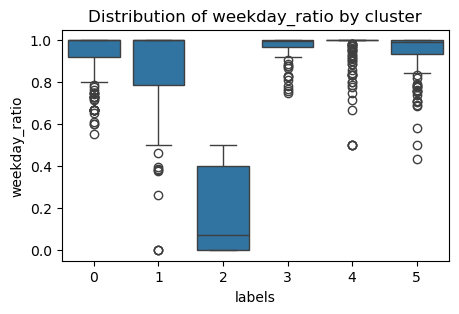

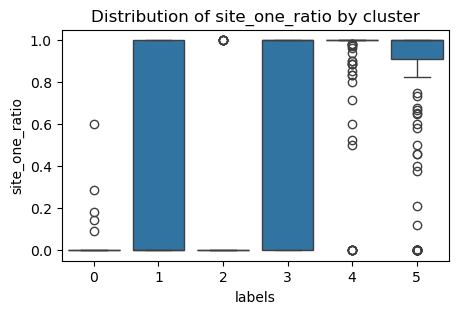

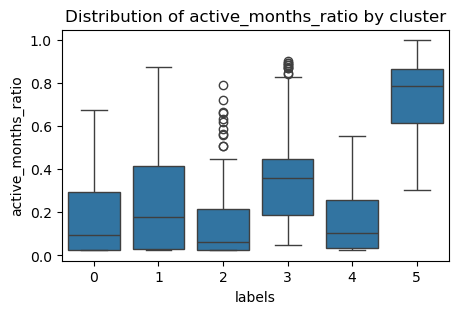

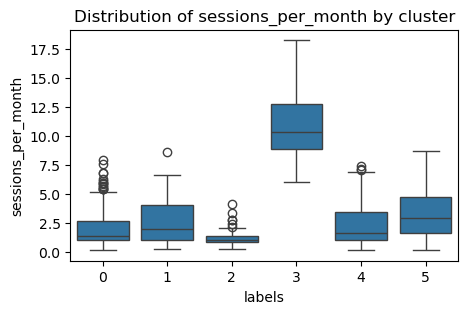

In [94]:
for f in features:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x="labels", y=f, data=X)
    plt.title(f"Distribution of {f} by cluster")
    plt.savefig(f"Cluster_results_analysis/Boxplots/{f}")
    plt.show()

## Cluster Results and Domain Interpretation

The clustering analysis resulted in six distinct user groups, each representing a characteristic charging behavior pattern with respect to usage frequency, temporal preferences, blocking behavior, and location choice. The clusters are summarized and interpreted as follows.

#### Cluster 0 — Campus Visitors (201 users)
Users in this cluster exhibit short charging and blocking durations and charge almost exclusively on weekdays at the public charging site of the university. Their activity spans only a small fraction of the observation period, with low session frequency. This group represents infrequent, compliant public users with minimal impact on charging infrastructure.

#### Cluster 1 — Charger hogs (67 users)
This cluster is characterized by exceptionally high blocking times despite average charging durations. Users primarily charge at the public site and show moderate activity and session frequency. From a domain perspective, these users occupy charging points long after charging completion, making them a critical group for congestion management and policy interventions such as idle fees or behavioral nudges.

#### Cluster 2 — Weekend Visitors (76 users)
Users in this cluster charge predominantly on weekends at the public site, with very short charging and blocking times. They show low long-term activity and the lowest session frequency across all clusters. This group represents casual or opportunistic users, such as visitors, with negligible infrastructure impact.

#### Cluster 3 — Local Dependents (96 users)
Users in this cluster exhibit very high session frequencies, strong weekday usage, and long-term activity. Charging occurs at both private and public sites, accompanied by slightly higher blocking behavior. This pattern suggests users who rely heavily on the local charging infrastructure. The mixed-site usage and frequent charging are consistent with users who live nearby and may lack access to private home charging, making them a key group for capacity planning and infrastructure reliability.

#### Cluster 4 — Workplace Occasionals (259 users)
Users in this cluster charge exclusively at the private site (site one) and almost entirely on weekdays. While their session frequency is low to moderate, their overall activity duration is limited. This group represents typical workplace chargers who use the infrastructure occasionally without placing significant strain on capacity.

#### Cluster 5 — Workplace Regulars (189 users)
This cluster consists of long-term, consistent users who charge primarily at the private site during weekdays. They show high activity over the observation period with moderate session frequency. Compared to workplace occasional users, this group exhibits substantially higher blocking times, indicating more routine-driven and less time-sensitive charging behavior. These users form the stable backbone of private-site charging demand and are well suited for demand forecasting or subscription-based charging models. 

<br>

Overall, the six-cluster solution reveals distinct and interpretable charging behaviors. The clusters provide actionable insights for business improvement. Interventions like idle fees or reminders can address “Charger Hogs,” while understanding “Workplace Regulars” and “Local Dependents” helps optimize capacity and forecast demand. Targeted programs for occasional or weekend users can increase engagement and encourage off-peak usage. Overall, the analysis enables more efficient operations, better user satisfaction, and improved revenue opportunities.
